# Oppgave 1d)

In [14]:
# FRA FORRIGE OPPGAVE, TRENGER IKKE Å KOPIERES INN I MAIN

import numpy as np
import matplotlib.pyplot as plt


def RungeKutta_32(x_init, x_end, y_init, f, alpha, h_0, tol):
    n = 0                           # Teller antall steg som aksepteres
    n_total = 0                     # Teller antall steg som testes
    h_n = h_0                       # Steglengde ved steg n
    x_n = x_init                    # x-verdi ved steg n
    y_n = y_init                    # y-vektor ved steg n
    
    x_array = [x_n]                 # Liste til x-verdier for hvert steg
    y_matrix = [y_n]                # 2D-liste med y-vektor for hvert steg 
    step_array = []                 # Liste til steglengde for hvert steg


    k_1 = f(x_init, y_init)

    while (x_end - x_n) > 0:
        h_n = min(h_n, x_end - x_n)
        k_2 = f(x_n + (1/2)*h_n, y_n + (1/2)*h_n*k_1)
        k_3 = f(x_n + (3/4)*h_n, y_n + (3/4)*h_n*k_2)

        y_next = y_n + (1/9)*h_n*(2*k_1 + 3*k_2 + 4*k_3)                # Midlertig oppdatering av y
        x_next = x_n + h_n                                              # Oppdatering av x

        k_4 = f(x_next, y_next)
        z_next = y_n + (1/24)*h_n*(7*k_1 + 6*k_2 + 8*k_3 + 3*k_4)       # Beregner alternativ y for sammenligning

        est = abs(y_next[0] - z_next[0])
        if est < tol:                                                   # Sjekker om skrittet aksepteres
            n += 1                                                      # Oppdaterer antall skritt
            k_1 = k_4                                                   # Oppdaterer k_1
            
            x_array.append(x_next)                                      # Legger til x-verdi i listen siden skrittet aksepteres
            y_matrix.append(y_next)                                     # Legger til y-vektor i listen siden skrittet aksepteres
            step_array.append(h_n)                                      # Legger til steglengde i listen siden skrittet aksepteres
            
            x_n = x_next                                                # Oppdaterer x-verdi siden skrittet aksepteres
            y_n = y_next                                                # Oppdaterer y-vektor siden skrittet aksepteres

        h_new = alpha*h_n*(tol/est)**(1/3)                              # Beregner ny steglengde  
        h_n = h_new                                                     # Oppdaterer steglengden

        n_total += 1                                                    # Oppdaterer antall testede skritt



    return np.array(x_array), np.array(y_matrix), np.array(step_array), n, n_total

In [15]:
alpha = 0.8
h_0 = 0.01

x_init, x_end = 0, 2*np.pi
y_init = np.array([0, 2])

def f_array(x, y_array):                                                   # Definerer f som returnerer vektor
    f = -4*np.sin(2*x)                                                    
    f_array = np.array([y_array[1], f])
    return f_array

In [17]:
# HER BEGYNNER DET NYE SOM SKAL KOPIERES INN

def analyticalSolution(x):                          # Funksjon for å beregne analytisk løsning
    y = np.sin(2*x)
    return y


def maxActualError(x_init, x_end, y_init, f_array, alpha, h_0, tol):
    x_values, y_matrix, step_array, n, n_total = RungeKutta_32(x_init, x_end, y_init, f_array, alpha, h_0, tol) 
    y_values_RK = [y_vector[0] for y_vector in y_matrix] 

    y_values_analytical = analyticalSolution(x_values) # Liste med analytisk løsning 

    error = abs(y_values_analytical - y_values_RK)     # Beregner absoluttfeil i alle punkter
    maxError = max(error)                              # Finner største feilen

    return maxError



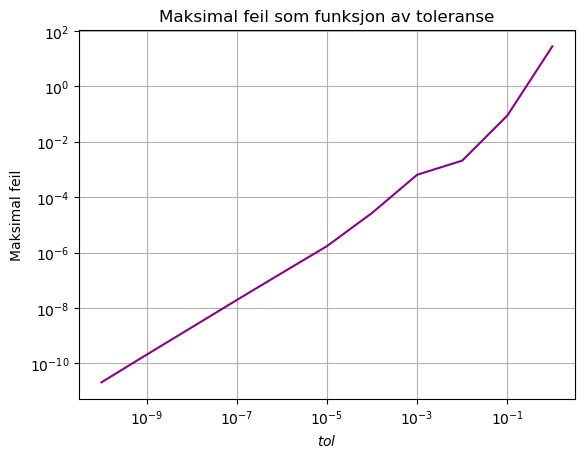

In [22]:
tol_array = np.array([10**i for i in range(-10, 1)])
maxError_array = []
for tol in tol_array:
    maxError_array.append(maxActualError(x_init, x_end, y_init, f_array, alpha, h_0, tol))


plt.plot(tol_array, maxError_array, color = 'darkmagenta')
plt.title('Maksimal feil som funksjon av toleranse')

plt.xlabel('$tol$')
plt.xscale('log')
plt.xticks(tol_array)
plt.yscale('log')
plt.ylabel('Maksimal feil')

plt.grid()
plt.show()

In [26]:
alpha_array = np.linspace(0.1, 0.8, 20)
tolerance = 10^(-7)

n_array = []                                        # Liste for antall aksepterte tidssteg
n_total_array = []                                  # Liste for totalt antall testede tidssteg

for alphaValue in alpha_array:                      # Itererer gjennom alle alfaverdier
    x_values, y_matrix, step_array, n, n_total = RungeKutta_32(x_init, x_end, y_init, f_array, alphaValue, h_0, tolerance)
    n_array.append(n)           
    n_total_array.append(n_total)


/var/folders/y4/g4lt_ymx5030y3d_whlnmf_00000gn/T/ipykernel_70144/3005949023.py:43: RuntimeWarning: invalid value encountered in scalar power
  h_new = alpha*h_n*(tol/est)**(1/3)                              # Beregner ny steglengde


KeyboardInterrupt: 

In [23]:
plt.plot(alpha_array, n_array, label = 'Aksepterte tidssteg', color = 'brown')
plt.plot(alpha_array, n_total_array, label = 'Totalt antall testede tidssteg', color = 'blueviolet')
plt.xlabel('α')
plt.ylabel('Tidssteg')
plt.legend()
plt.grid()
plt.show()

NameError: name 'alpha_array' is not defined